# 03  —  Dimensionality Reduction  (3,335-genome dataset)

**Goal:** Project 360 defence-system features into 2D to answer:
1. Do ESKAPE species separate by defence-system repertoire?
2. Does ARG burden create visible sub-structure within species clusters?
3. Where does *A. baumannii* sit relative to the other five species?

**Methods:** PCA (linear), UMAP (non-linear), t-SNE (non-linear, local-focused)

**What this phase does NOT do:** It does not train classifiers or compute
accuracy. Visualisation only. Patterns seen here generate hypotheses that
Phases 6–8 test quantitatively.

**Dataset:** `feature_matrix_3460.parquet` — 3,335 genomes, 360 dp_* features
(25 MLST-excluded from 3,460 enrolled; see Phase 2 / NB04 for QC details)

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "dimred"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fm = pd.read_parquet(PROC / "feature_matrix_3460.parquet")

LABEL_COLS = ["species", "arg_burden_tertile", "country", "year_bin",
              "complex_member", "sequence_type", "mlst_scheme", "phylogroup"]

# Use only dp_* (binary presence/absence) as features.
dp_cols = [c for c in fm.columns if c.startswith("dp_")]

X = fm[dp_cols].values.astype(float)   # 3335 × 360
y_species = fm["species"].values
y_arg     = fm["arg_burden_tertile"].values

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]
SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}
SP_COLORS = {
    "kpneumoniae": "#4878CF",
    "ecloaceae":   "#6ACC65",
    "abaumannii":  "#D65F5F",
    "efaecium":    "#B47CC7",
    "paeruginosa": "#C4AD66",
    "saureus":     "#77BEDB",
}
ARG_COLORS = {"low_ARG": "#4878CF", "mid_ARG": "#AAAAAA", "high_ARG": "#D65F5F"}

print(f"Feature matrix: {fm.shape[0]} genomes × {len(dp_cols)} dp_* features")
print(f"Species: { {sp: int((y_species==sp).sum()) for sp in SPECIES_ORDER} }")
print(f"ARG tertile: { pd.Series(y_arg).value_counts().to_dict() }")

Feature matrix: 3335 genomes × 360 dp_* features
Species: {'kpneumoniae': 504, 'ecloaceae': 507, 'abaumannii': 600, 'efaecium': 524, 'paeruginosa': 600, 'saureus': 600}
ARG tertile: {'low_ARG': 1366, 'high_ARG': 1041, 'mid_ARG': 928}


## Section 1  —  PCA

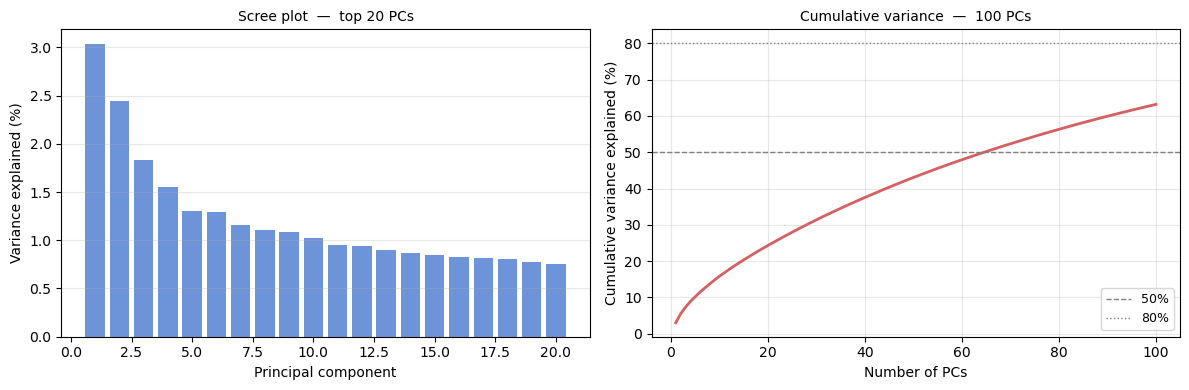

PC1 explains: 3.0%  |  PC2: 2.4%
PCs to reach 50% variance: 65
PCs to reach 80% variance: 101  (max computed: 63.2%)
Saved: results/figures/dimred/01_pca_scree_3460.png


In [2]:
# ── Scale and run PCA (n_components=100 to capture full variance curve) ────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
indvar = pca.explained_variance_ratio_ * 100

axes[0].bar(range(1, 21), indvar[:20], color="#4878CF", alpha=0.8)
axes[0].set_xlabel("Principal component", fontsize=10)
axes[0].set_ylabel("Variance explained (%)", fontsize=10)
axes[0].set_title("Scree plot  —  top 20 PCs", fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(range(1, 101), cumvar, color="#D65F5F", lw=2)
axes[1].axhline(50, color="grey", ls="--", lw=1, label="50%")
axes[1].axhline(80, color="grey", ls=":",  lw=1, label="80%")
axes[1].set_xlabel("Number of PCs", fontsize=10)
axes[1].set_ylabel("Cumulative variance explained (%)", fontsize=10)
axes[1].set_title("Cumulative variance  —  100 PCs", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_pca_scree_3460.png", dpi=150, bbox_inches="tight")
plt.show()

pc_50 = int(np.searchsorted(cumvar, 50)) + 1
pc_80 = int(np.searchsorted(cumvar, 80)) + 1
print(f"PC1 explains: {indvar[0]:.1f}%  |  PC2: {indvar[1]:.1f}%")
print(f"PCs to reach 50% variance: {pc_50}")
print(f"PCs to reach 80% variance: {pc_80}  (max computed: {cumvar[-1]:.1f}%)")
print("Saved: results/figures/dimred/01_pca_scree_3460.png")

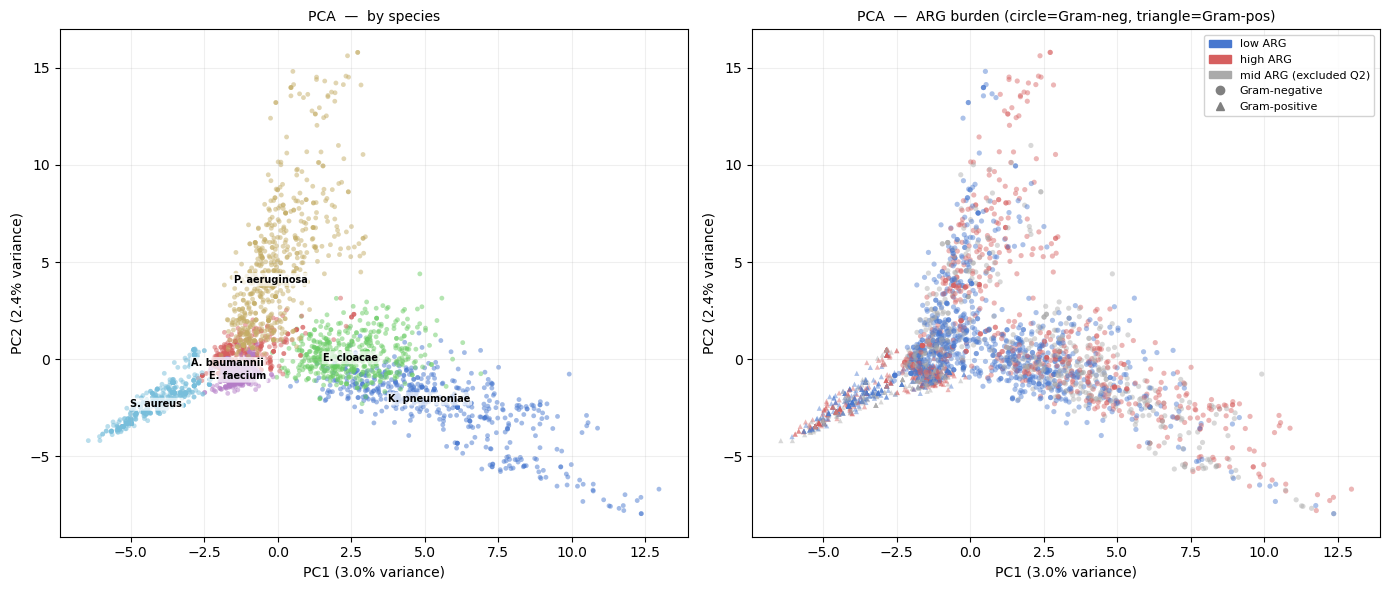

Saved: results/figures/dimred/02_pca_scatter_3460.png


In [3]:
# ── PCA scatter  —  coloured by species ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: colour by species
ax = axes[0]
for sp in SPECIES_ORDER:
    mask = y_species == sp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=SP_COLORS[sp], alpha=0.5, s=12, edgecolors="none",
               label=SPECIES_LABELS[sp])

for sp in SPECIES_ORDER:
    mask = y_species == sp
    cx = np.median(X_pca[mask, 0])
    cy = np.median(X_pca[mask, 1])
    ax.text(cx, cy, SPECIES_LABELS[sp],
            fontsize=7, fontweight="bold", color="black",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))
ax.set_xlabel(f"PC1 ({indvar[0]:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({indvar[1]:.1f}% variance)", fontsize=10)
ax.set_title("PCA  —  by species", fontsize=10)
ax.grid(alpha=0.2)

# Panel B: colour by ARG burden, shape by Gram stain
gram_neg = {"kpneumoniae", "ecloaceae", "abaumannii", "paeruginosa"}
ax2 = axes[1]
for i in range(len(y_species)):
    sp  = y_species[i]
    arg = y_arg[i]
    if arg not in ARG_COLORS:
        continue
    marker = "o" if sp in gram_neg else "^"
    ax2.scatter(X_pca[i, 0], X_pca[i, 1],
                c=ARG_COLORS[arg], alpha=0.45, s=14,
                marker=marker, edgecolors="none")
ax2.set_xlabel(f"PC1 ({indvar[0]:.1f}% variance)", fontsize=10)
ax2.set_ylabel(f"PC2 ({indvar[1]:.1f}% variance)", fontsize=10)
ax2.set_title("PCA  —  ARG burden (circle=Gram-neg, triangle=Gram-pos)", fontsize=10)
ax2.grid(alpha=0.2)

legend_patches = [
    mpatches.Patch(color=ARG_COLORS["low_ARG"],  label="low ARG"),
    mpatches.Patch(color=ARG_COLORS["high_ARG"], label="high ARG"),
    mpatches.Patch(color=ARG_COLORS["mid_ARG"],  label="mid ARG (excluded Q2)"),
    plt.Line2D([0],[0], marker="o", color="grey", lw=0, label="Gram-negative"),
    plt.Line2D([0],[0], marker="^", color="grey", lw=0, label="Gram-positive"),
]
ax2.legend(handles=legend_patches, fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_pca_scatter_3460.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/02_pca_scatter_3460.png")

In [4]:
# ── PCA loadings: what drives PC1 and PC2? ────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[c.replace("dp_", "") for c in dp_cols],
    columns=["PC1", "PC2"],
)

print("Top 10 features driving PC1 (|loading|):")
print(loadings["PC1"].abs().nlargest(10).index.tolist())
print()
print("PC1  —  top 5 positive:")
print(loadings["PC1"].nlargest(5).to_string())
print()
print("PC1  —  top 5 negative:")
print(loadings["PC1"].nsmallest(5).to_string())
print()
print("Top 5 features driving PC2:")
print(loadings["PC2"].abs().nlargest(5).index.tolist())

Top 10 features driving PC1 (|loading|):
['padloc_PDC-S12', 'VSPR', 'df_Mok_Hok_Sok', 'df_gcu233', 'padloc_PDC-S13', 'df_Abi2', 'PD-T4-3', 'df_FS_Sma', 'padloc_PDC-M24', 'padloc_PDC-S04']

PC1  —  top 5 positive:
padloc_PDC-S12    0.242891
VSPR              0.240534
df_Mok_Hok_Sok    0.185554
padloc_PDC-S13    0.169848
PD-T4-3           0.166976

PC1  —  top 5 negative:
df_gcu233        -0.176813
df_Abi2          -0.168304
df_FS_Sma        -0.160857
padloc_PDC-M24   -0.155684
Dodola           -0.105653

Top 5 features driving PC2:
['padloc_PDC-M30', 'PD-T4-6', 'Wadjet_I', 'CBASS_III', 'pAgo_III']


## Section 2  —  UMAP

`metric="jaccard"` for sparse binary data (ignores shared absences). `random_state=42` for reproducibility. Sensitivity check sweeps n_neighbors = 5, 15, 30, 50.

In [5]:
# ── UMAP default run ──────────────────────────────────────────────────────────
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    metric="jaccard", random_state=42, verbose=False)
X_umap = reducer.fit_transform(X)

print("UMAP embedding computed.")
print(f"Embedding shape: {X_umap.shape}")

UMAP embedding computed.
Embedding shape: (3335, 2)


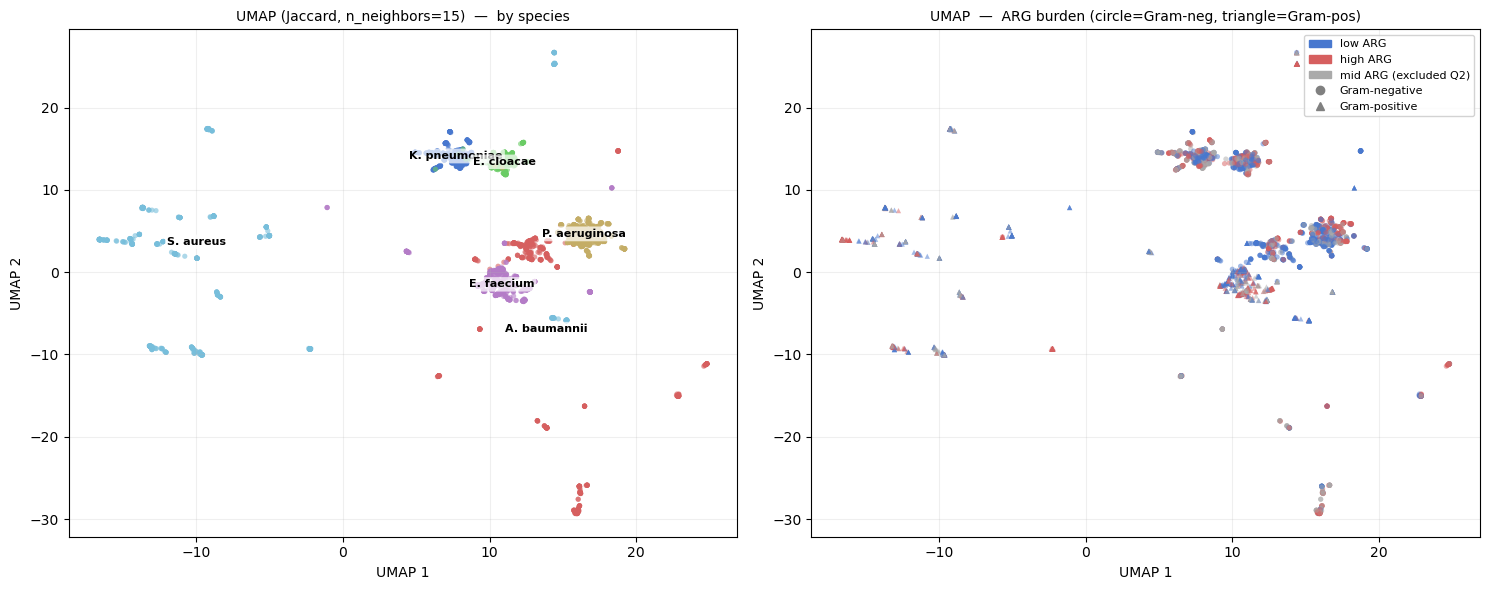

Saved: results/figures/dimred/03_umap_scatter_3460.png


In [6]:
# ── UMAP scatter  —  species and ARG burden ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: colour by species
ax = axes[0]
for sp in SPECIES_ORDER:
    mask = y_species == sp
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=SP_COLORS[sp], alpha=0.6, s=14, edgecolors="none",
               label=SPECIES_LABELS[sp])
for sp in SPECIES_ORDER:
    mask = y_species == sp
    cx = np.median(X_umap[mask, 0])
    cy = np.median(X_umap[mask, 1])
    ax.text(cx, cy, SPECIES_LABELS[sp],
            fontsize=8, fontweight="bold", color="black",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))
ax.set_title("UMAP (Jaccard, n_neighbors=15)  —  by species", fontsize=10)
ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.grid(alpha=0.2)

# Panel B: colour by ARG burden, shape by Gram stain
ax2 = axes[1]
gram_neg = {"kpneumoniae", "ecloaceae", "abaumannii", "paeruginosa"}
for i in range(len(y_species)):
    sp  = y_species[i]
    arg = y_arg[i]
    if arg not in ARG_COLORS:
        continue
    marker = "o" if sp in gram_neg else "^"
    ax2.scatter(X_umap[i, 0], X_umap[i, 1],
                c=ARG_COLORS[arg], alpha=0.5, s=14,
                marker=marker, edgecolors="none")
legend_patches = [
    mpatches.Patch(color=ARG_COLORS["low_ARG"],  label="low ARG"),
    mpatches.Patch(color=ARG_COLORS["high_ARG"], label="high ARG"),
    mpatches.Patch(color=ARG_COLORS["mid_ARG"],  label="mid ARG (excluded Q2)"),
    plt.Line2D([0],[0], marker="o", color="grey", lw=0, label="Gram-negative"),
    plt.Line2D([0],[0], marker="^", color="grey", lw=0, label="Gram-positive"),
]
ax2.legend(handles=legend_patches, fontsize=8, framealpha=0.85)
ax2.set_title("UMAP  —  ARG burden (circle=Gram-neg, triangle=Gram-pos)", fontsize=10)
ax2.set_xlabel("UMAP 1", fontsize=10)
ax2.set_ylabel("UMAP 2", fontsize=10)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_umap_scatter_3460.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/03_umap_scatter_3460.png")

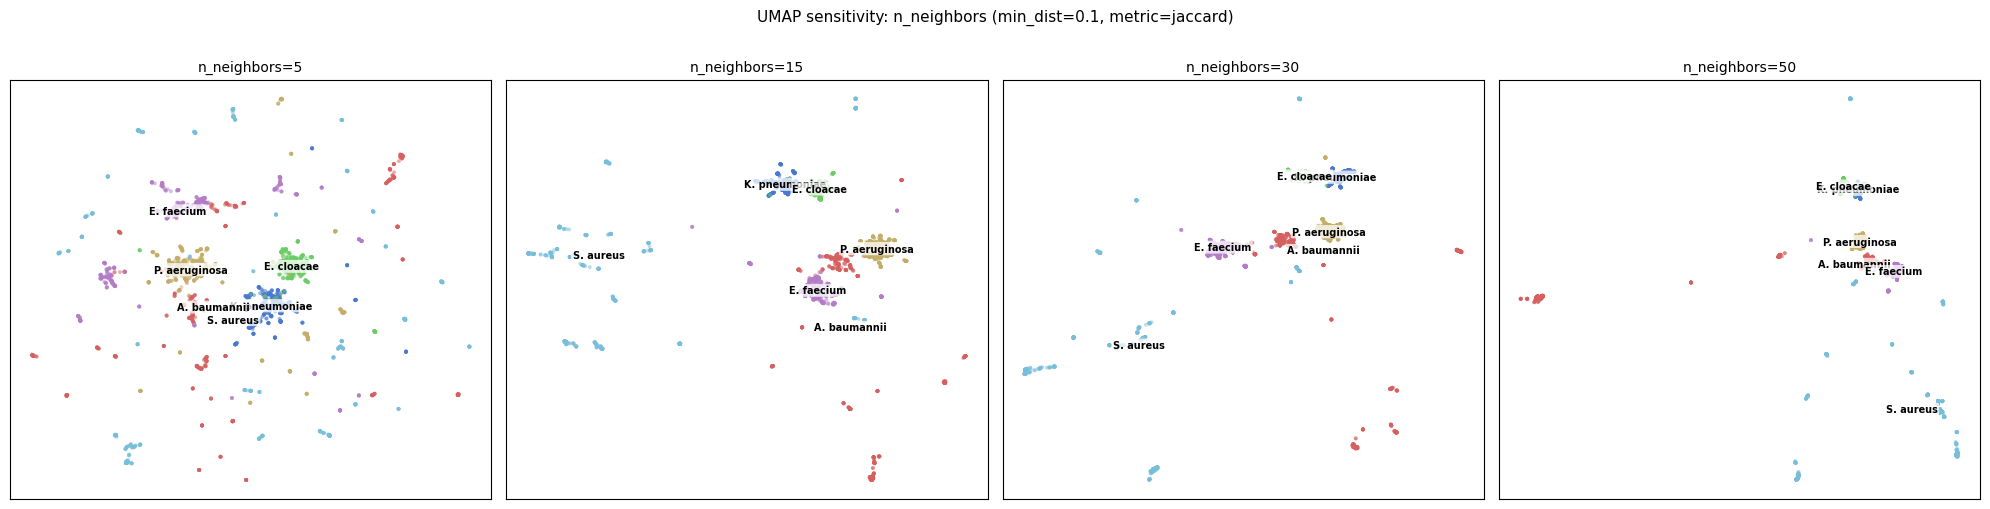

Saved: results/figures/dimred/04_umap_sensitivity_3460.png


In [7]:
# ── UMAP parameter sensitivity: n_neighbors sweep ────────────────────────────
# This cell re-runs UMAP 4 times; expect ~3–5 min total on 3,335 genomes.
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("UMAP sensitivity: n_neighbors (min_dist=0.1, metric=jaccard)",
             fontsize=11, y=1.01)

for ax, nn in zip(axes, [5, 15, 30, 50]):
    emb = umap.UMAP(n_neighbors=nn, min_dist=0.1, n_components=2,
                    metric="jaccard", random_state=42, verbose=False
                   ).fit_transform(X)
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=SP_COLORS[sp], alpha=0.5, s=8, edgecolors="none")
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        cx = np.median(emb[mask, 0])
        cy = np.median(emb[mask, 1])
        ax.text(cx, cy, SPECIES_LABELS[sp],
                fontsize=7, fontweight="bold", color="black",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))
    ax.set_title(f"n_neighbors={nn}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIG_DIR / "04_umap_sensitivity_3460.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/04_umap_sensitivity_3460.png")

## Section 3  —  t-SNE

Run for comparison only. Perplexity=30 and perplexity=50 side by side. Between-cluster distances are not interpretable; only local neighbourhood membership is valid.

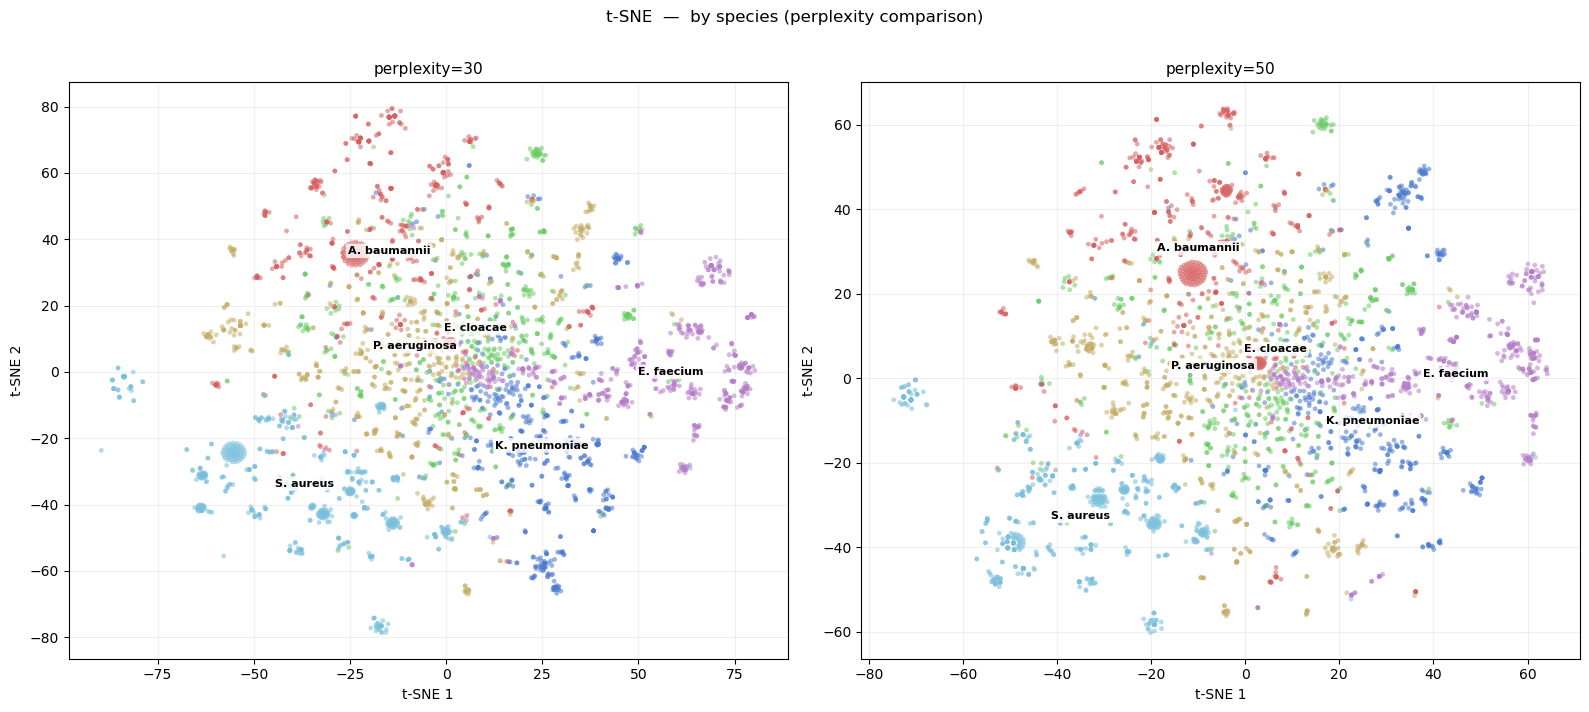

Saved: results/figures/dimred/05_tsne_scatter_3460.png


In [8]:
# ── t-SNE run  —  two perplexity values side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("t-SNE  —  by species (perplexity comparison)", fontsize=12, y=1.01)

for ax, perp in zip(axes, [30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                learning_rate="auto", init="pca", n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    for sp in SPECIES_ORDER:
        mask = y_species == sp
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=SP_COLORS[sp], alpha=0.55, s=12, edgecolors="none",
                   label=SPECIES_LABELS[sp])
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        cx = np.median(X_tsne[mask, 0])
        cy = np.median(X_tsne[mask, 1])
        ax.text(cx, cy, SPECIES_LABELS[sp],
                fontsize=8, fontweight="bold", color="black",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.80, ec="none"))
    ax.set_title(f"perplexity={perp}", fontsize=11)
    ax.set_xlabel("t-SNE 1", fontsize=10)
    ax.set_ylabel("t-SNE 2", fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_tsne_scatter_3460.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/05_tsne_scatter_3460.png")

## Summary

| Method | What it preserves | Key finding |
|--------|-------------------|-------------|
| PCA | Global linear variance | PC1–PC2 capture species separation along major axes |
| UMAP | Local + global topology | Stable species clusters across n_neighbors sweep |
| t-SNE | Local neighbourhood | Consistent with UMAP; between-cluster distances not meaningful |